# Activity 3 — Neuroevolution vs Deep Q-Network on LunarLander-v3


In [108]:
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import gymnasium as gym
from dataclasses import dataclass,field

# Configuration classes

In [ ]:
# Dataclass is used to store attribute values for experiments and configuration replicability.
@dataclass
class DQNConfig:
    """
        Configuration class for DQN experiments.
    """
    dqn_episodes: int = 1000 # number of episodes to train the DQN agent
    dqn_gamma: float = 0.99 # discount factor for future rewards
    dqn_learning_rate: float = 1e-3 # learning rate for the optimizer other hyperparameters can be tuned for better performance
    dqn_batch_size: int = 64 # batch size for sampling from the replay buffer
    dqn_warmup_steps: int = 3000 # number of steps to populate the replay buffer before training starts
    dqn_target_sync: int = 1000 # number of steps between target network updates
    dqn_epsilon_start: float = 1.0 # initial epsilon for epsilon-greedy exploration
    dqn_epsilon_decay: float = 0.995 # decay rate for epsilon after each episode
    dqn_epsilon_min: float = 0.05 # minimum epsilon for exploration
    dqn_buffer_capacity: int = 10000 # capacity of the replay buffer

@dataclass
class GeneticAlgorithmConfig:
    """
        Configuration class for Genetic Algorithm experiments.
    """
    ga_population_size: int = 100 # number of genomes in the population, higher can improve performance but takes longer to evaluate
    ga_n_elite: int = 10 # number of top-performing genomes to carry over unchanged to the next generation, higher can speed up convergence but may reduce diversity
    ga_generations: int = 150 # number of generations to run the genetic algorithm, higher can improve performance but takes longer
    ga_mutation_rate: float = 0.02 # probability of mutating each gene in a genome, higher can increase diversity but may slow convergence
    ga_eval_episodes: int = 1 # number of episodes to evaluate each genome for fitness, higher can give more stable fitness estimates but takes longer, but since we are evaluating many genomes per generation we can keep this low for faster iterations

@dataclass
class Experiment:
    """
        Base class for experiment configuration.
    """
    seed: int = 112    
    eval_episodes: int = 3 # Number of episodes to evaluate each genome for fitness, higher can give more stable fitness estimates but takes longer.
    # This is pending implementation, but can be useful to maintain different experiments, specifically for hyperparameter tuning research.
    results_dir: Path = field(default_factory=lambda: Path("results/lunar_lander"))
    save_figures: bool = True
    show_figures: bool = True
    show_training: bool = True

    dqn: DQNConfig = field(default_factory=DQNConfig)
    ga: GeneticAlgorithmConfig = field(default_factory=GeneticAlgorithmConfig)


def set_seeds(seed: int):
    """
        Set random seeds for reproducibility.
        Args:
            seed (int): The seed value to set for random, numpy, and torch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

# Set device for PyTorch computations (GPU if available, otherwise CPU).
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [110]:
LUNAR_ACTIONS = [
    "no-op",
    "left engine",
    "main engine",
    "right engine",
]

CARTPOLE_ACTIONS = [
    "left",
    "right",
]

# DQN

## Q Network Implementation

The Q network, $Q_\theta(s,\cdot)$ is implemented as a connected Neural Netword (NN) that output is the action value. Given a state ($s$), the network outputs a vector with the Q-value for each action ($A$) available.
$$Q\theta(s,\dot)\in\mathbb{R}^{|A|}$$

The implemented architecture has two hiddne layers of 128 neurons and ReLU activation functions. Depending of the simulation environment (CartPole or LunarLander) different output exist:
For CartPole:
$$4 \rightarrow 128 \rightarrow 128 \rightarrow 2$$
For LunarLander:
$$8 \rightarrow 128 \rightarrow 128 \rightarrow 4$$

The final layer is, as mentioned above, the action taken.
$$Q_\theta(s,) = \left[ Q_\theta(s,a_1), Q_\theta(s,a_2), \dots, Q_\theta(s,a_{|A|}) \right]$$

Agent follows a greedy policy and takes the action associated with highest Q-value
$$a = \arg\max_a Q\theta(s,a)$$

For exploitation and exploration balance, greedy strategy is used. With $\varepsilon$, the agent select a random action and explores environment. With $1 - \varepsilon$, exploits current by selecting the greedy action:
$$a = \begin{cases} 
    \text{Random Action}, & \text{with prob: } \varepsilon\arg\max_a Q\theta(s,a) \\
                          & \text{with prob: } 1 -\varepsilon
                          \end{cases}
$$



The rate for exploration of random actions is set at $\varepsilon = 1.0$ and decay after each episode based on:
$$
    \varepsilon = \max(\varepsilon_{\min}, \varepsilon \times \varepsilon_{\text{decay}})
$$ 

With the configuration from above, we do more exploration at the start of the training, and we transition to a more exploit based process as the agent progress with the learning.



## Replay

A difficulty for reinforcement learning is that some experiences can be highly correlated. Train directly in sequential steps and observations can produce poor convergence because the NN observe similar transitions between states. To sove this, we can implement a replay buffer which stores some "experiences" in the agent learning phase. Each transition can be represented as:
$$ (s_t, a_t, r_t, s_{t+1}, d_t)$$

Where $(s_t)$ is the current state, $(a_t)$ the action executed, $(r_t)$ the reward received, $(s_{t+1})$ is the next state, and $(d_t)$ tell us if the episode is finished.

The replay buffer can be implemented as a queue with a limited capacity, where new transitions can be stored during training and oldest are discarded when maximum capacity is reached. To have less correlation between transitions the agent select random transitions from the buffer. 

When training, at each time step and an action is selected, the environment store the resulting transition in the replay buffer. When enough are selected the batches of transitions are sampled and are used to calculate the gradient updates.

## Bellman target computation and target networks

As we need to learn an approximation of the optimal action function $Q^*(s,a)$, representing the maximum expected return after taking an action in a state. Learning is performed using Bellman Equation:
$$
    r_t + \gamma \max_a Q^*(s_{t+1},a)
$$
The equation gives the value of a state-action tuple as the immediate reward plus a the best available action in the next state, that discounted by a $\gamma$ value.

In training, we have the online network $Q\theta$ that results in the current Q values. Using a sampled of replay buffer, the values from the output associated with actions are extracted as:
$$Q_\theta(s_t,a_t)$$

The results corresponds to the current estimation of the aaction-value function, which are obtained from the online network. The target value are calculated using a target network $Q_{\theta^-}$

$$r_t + \gamma \max_a Q_{\theta^-}(s_{t+1},a)$$

The target network is critical in stabilizing the learning phase. Then we maintain two networks
- Online network, which is optimized thru gradient descent
- Target network, which is used for target computation only

At start, both contain same params. When training steps advances, the online network is updated by gradient steps, while the target remains "static" in that sense. At X steps, a synchronization of the parameters from the online network are copied into the target network. This sync happens when total steps is a multiple of target sync steps, which is a configurable parameter. The difference between the Q values outputs and the targets from Bellman equation are minimized using the Mean Square Error (MSE) loss function. Adam optimizer was selected to update the parameter for online network.

In [223]:
from collections import deque


class QNetwork(torch.nn.Module):
    """
        Simple feedforward neural network for approximating Q-values.        
    """
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128) -> None:
        """
            Initialize the Q-network.
            Args:
                state_dim (int): Dimension of the state space.
                action_dim (int): Dimension of the action space.
                hidden_dim (int): Number of neurons in the hidden layers.
            Returns:
                None
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
            Forward pass through the network.
            Args:
                x (torch.Tensor): Input state tensor.
            Returns:
                torch.Tensor: Output tensor with Q-values for each action.
        """
        return self.net(x)
        
class DQNAgent:
    """" 
        Deep Q-Network (DQN) agent for reinforcement learning.
    """

    def __init__(self, state_dim: int, action_dim:int, config: Experiment) -> None:
        self.config = config
        self.gamma = config.dqn.dqn_gamma
        self.batch_size = config.dqn.dqn_batch_size
        self.target = config.dqn.dqn_target_sync
        self.warmup_steps = config.dqn.dqn_warmup_steps
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.q_network = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_network = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=config.dqn.dqn_learning_rate)
        self.epsilon = config.dqn.dqn_epsilon_start
        self.epsilon_decay = config.dqn.dqn_epsilon_decay
        self.epsilon_min = config.dqn.dqn_epsilon_min
        self.total_steps = 0

        self.replay_buffer = ReplayBuffer(config.dqn.dqn_buffer_capacity)


    def action(self, state: np.ndarray, train: bool = True) -> int:
        """
        Select an action using epsilon-greedy policy.
        Args:
            state (np.ndarray): The current state.
            train (bool): Whether to train the agent.
        Returns:
            int: The selected action.
        """
        # if we are in training mode and a random number is less than epsilon, select a random action,
        # otherwise select the action with the highest Q-value from the network.
        if train and random.random() < self.epsilon:
            return random.randrange(self.action_dim) 
        
        # Convert state to tensor and add batch dimension
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        # Get Q-values from the network, 
        # torch.no_grad() is used to disable grad calc, we only want the values, not to compute gradients
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        
        # Return the action with the highest Q-value
        return int(q_values.argmax(dim=1).item())
    
    def sample_batch(self) -> tuple:
        """
            Sample a batch of experiences from the replay buffer.
            Returns:
                tuple: A tuple containing the sampled experiences.
        """
        return self.replay_buffer.sample(self.batch_size)
    
    def compute_current_q(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        """
            Compute the current Q-values for the given states and actions.
            Args:
                states (torch.Tensor): Batch of states.
                actions (torch.Tensor): Batch of actions.
            Returns:
                torch.Tensor: Current Q-values for the given states and actions.
        """
        # Get Q-values for the current states and actions (batch_size, action_dim)
        q_values = self.q_network(states)
        # (batch_size, 1) 
        action_index = actions.unsqueeze(1)
        # (batch_size, 1)
        selected_q_values = q_values.gather(dim=1, index=action_index)
        # (batch_size,)
        return selected_q_values.squeeze(1)
    
    def compute_target_q(self, rewards: torch.Tensor, next_states: torch.Tensor, dones: torch.Tensor) -> torch.Tensor:
        """
            Compute the target Q-values using the Bellman equation.
            Args:
                rewards (torch.Tensor): Batch of rewards.
                next_states (torch.Tensor): Batch of next states.
                dones (torch.Tensor): Batch of done flags.
            Returns:
                torch.Tensor: Target Q-values for the given rewards, next states, and done flags.
        """
        with torch.no_grad():
            # Get the Q-values for the next states from the target network
            next_q_values = self.target_network(next_states)
            # Get the maximum Q-values for the next states (batch_size,)
            max_next_q_values, _ = next_q_values.max(dim=1)
            # Compute the target Q-values using the Bellman equation
            # target_q = reward + gamma * max_next_q * (1 - done)
            target_q_values = rewards + self.gamma * max_next_q_values * (1 - dones)
        return target_q_values
    
    def compute_loss(self, current_q: torch.Tensor, target_q: torch.Tensor) -> torch.Tensor:
        """
            Compute the mean squared error loss between current Q-values and target Q-values.
            Args:
                current_q (torch.Tensor): Batch of current Q-values.
                target_q (torch.Tensor): Batch of target Q-values.
            Returns:
                torch.Tensor: The computed loss.
        """
        # Compute the mean squared error loss between current Q-values and target Q-values
        loss = nn.MSELoss()(current_q, target_q)
        return loss
    
    def optimize(self, loss: torch.Tensor) -> None:
        """
            Optimize the network parameters based on the computed loss.
            Args:
                loss (torch.Tensor): The computed loss.
        """
        # Zero the gradients is to prevent accumulation from previous steps
        self.optimizer.zero_grad()
        # Backpropagate the loss to compute gradients
        loss.backward()
        # Update the network parameters
        self.optimizer.step()
        # Clear the gradients for the next iteration
        self.optimizer.zero_grad()

    def train_step(self) -> float:
        """
            Perform a single training step for the DQN agent.
            Returns:
                float: The computed loss.
        """
        if len(self.replay_buffer) < self.batch_size:
            return -1 # Not enough data to train yet
        
        states, actions, rewards, next_states, dones = self.sample_batch()

        # Compute current Q-values and target Q-values
        current_q = self.compute_current_q(states, actions)
        target_q = self.compute_target_q(rewards, next_states, dones)

        # Compute the loss and optimize
        loss = self.compute_loss(current_q, target_q)
        self.optimize(loss)

        return float(loss.item())
    

class ReplayBuffer:
    """
        Replay buffer for storing and sampling experiences for DQN training.
    """

    def __init__(self, capacity: int) -> None:
        """
        Initialize the replay buffer with a given capacity.
        Args:
            capacity (int): The maximum number of experiences to store in the buffer.
        """
        self.capacity = capacity
        self.buffer: deque = deque(maxlen=capacity)
    
    def __len__(self) -> int:
        """
            Get the current size of the replay buffer.
            Returns:
                int: The current size of the replay buffer.
        """
        return len(self.buffer)
    
    def add(self, state: np.ndarray, action: int, reward: float, next_state: np.ndarray, done: bool) -> None:
        """
            Add a new experience to the replay buffer.
            Args:
                state (np.ndarray): The current state.
                action (int): The action taken.
                reward (float): The reward received.
                next_state (np.ndarray): The next state after taking the action.
                done (bool): Whether the episode has ended.
            Returns:
                None
        """
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int) -> tuple:
        """
            Sample a batch of experiences from the replay buffer.
            Args:
                batch_size (int): The number of experiences to sample.
            Returns:
                tuple: A tuple containing the sampled states, actions, rewards, next states, and done flags.
        """
        # sample a random batch of experiences from the buffer
        batch = random.sample(self.buffer, batch_size)
        # zip is used to transpose batch from list of tuples to tuple of list
        states, actions, rewards, next_states, dones = zip(*batch)

        states_t = torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions_t = torch.tensor(actions, dtype=torch.long, device=DEVICE)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

        return states_t, actions_t, rewards_t, next_states_t, dones_t


class DQNTrainer:
    """
        Responsible for training the DQN agent.
    """
    def __init__(self, env: gym.Env, agent: DQNAgent, config: Experiment) -> None:
        """
            Initialize the DQN trainer with the environment, agent, and configuration.
            Args:
                env (gym.Env): The environment to train on.
                agent (DQNAgent): The DQN agent to be trained.
                config (Experiment): The experiment configuration.
            Returns:
                None
        """
        self.env = env
        self.agent = agent
        self.config = config

        self.metrics = DQNMetrics()

    def train(self) -> None:
        """
            Train the DQN agent for a specified number of episodes.
        """

        for episode in range(self.config.dqn.dqn_episodes):
            state, _ = self.env.reset()
            # Initialize episode reward and done flag
            episode_reward = 0
            done = False
            # Loop until the episode is done (terminated V truncated)
            while not done:
                # Select an action using the agent's policy
                action = self.agent.action(state, train=True)
                # Take the action in the environment and observe the next state, reward, and done flag
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                # Store the experience in the replay buffer and perform a training step
                self.agent.replay_buffer.add(state, action, reward, next_state, done)

                loss = self.agent.train_step()

                if loss >= 0:
                    self.metrics.loss_history.append(loss)
                
                state = next_state
                episode_reward += reward
                self.agent.total_steps += 1

                # Update the target network at specified intervals to stabilize training
                if self.agent.total_steps % self.agent.target == 0:
                    # Copy the weights from the Q-network to the target network
                    self.agent.target_network.load_state_dict(self.agent.q_network.state_dict())

            # Decay epsilon after each episode, ensuring it doesn't go below the minimum value.
            self.agent.epsilon = max(self.agent.epsilon * self.agent.epsilon_decay, self.agent.epsilon_min)
            self.metrics.rewards_history.append(episode_reward)
            self.metrics.epsilon_history.append(self.agent.epsilon)

            if episode % 10 == 0 and self.config.show_training:
                print(f"Episode {episode} - Reward: {episode_reward:.2f} - Epsilon: {self.agent.epsilon:.3f} - Loss: {loss:.4f}")

@dataclass
class DQNMetrics:
    """
        Dataclass for storing metrics during DQN training.
    """
    rewards_history: list = field(default_factory=list)
    loss_history: list = field(default_factory=list)
    epsilon_history: list = field(default_factory=list)
    success_history: list = field(default_factory=list)
    # action metrics
    action_distribution: np.ndarray | None = None

# Genetic Algorithm approach

GenomeUtils is in charge of representing a genome of an individual into a NN. Genetic Algorithms (GA) use chromosomes instead neural network tensors, the parameters of the NN should be represented into a 1D genome.
$$
\theta = {W_1, b_1, W_2, b_2, \dots, W_n, b_n}
$$

The parameter set is transformed into a genome (chromosome) by concatenating all params into a 1D vector:

$$
g = [\theta_1,\theta_2,\theta_3,\dots,\theta_N]
$$

N represents the number of parameters of the NN. For CartPole it should be $4 \rightarrow 128 \rightarrow 128 \rightarrow 2 = 17410$. For LunarLander $8 \rightarrow 128 \rightarrow 128 \rightarrow 4 = 18180$ genes. Therefore, a chromosome encodes a NN policy and corresponds to a solution in the search space of the problem (gym simulation). Then we can represent a population as:

$$ P = {g_1, g_2 \dots g_M} $$

Where $M$ is the population size and each genome $g_i$ have a full parametrization of a policy network. During the evaluation, the genome is mapped back to the NN param space. The genome is injected into the weights and bias, reconstructing again the policy network
The reconstructed network is executed within the environment and receives a fitness score based on the reward obtained in the episode

$$ F(g) = \sum_{t=0}^{T} r_t$$

Where $r_t$ as above, represents the reward received at step $t$. Different from gradient RL methods, there are no params being updated by backpropagation. The search of the optimum is performed in the parameter space of the NN using evolutionary functions.

In [224]:
class GenomeUtils:
    @staticmethod
    def flatten(model: nn.Module) -> np.ndarray:
        """
            Flatten the parameters of a PyTorch model into a 1D numpy array.
            Args:
                model (nn.Module): The PyTorch model to flatten.
            Returns:
                np.ndarray: A 1D array containing all the parameters of the model.
        """
        # use CPU to ensure compatibility with numpy
        return np.concatenate([param.data.cpu().numpy().flatten() for param in model.parameters()])
    
    @staticmethod
    def inject(model: nn.Module, genome: np.ndarray) -> None:
        """
            Inject a flattened genome back into a PyTorch model params.
            Args:
                model (nn.Module): The PyTorch model to inject the genome into.
                genome (np.ndarray): A 1D array containing the parameters to inject.
            Returns:
                None
        """
        genome_index = 0
        for parameter in model.parameters():
            parameter_size = parameter.numel()

            parameter_values = genome[
                genome_index : genome_index + parameter_size
            ]

            parameter_values = parameter_values.reshape(
                parameter.shape
            )

            parameter_tensor = torch.tensor(
                parameter_values
            ).to(parameter.device)

            parameter.data.copy_(parameter_tensor)

            genome_index += parameter_size

From here the key concepts are:
### Tournament selection
The parents of the population are selected using the mentioned method. Instead of selecting the best individuals always a sample from the population is selected.
$$T = {g_1, g_2 \dots, g_k} $$

$k$ is the tournament size. The individual with the highest fitness is selected as parent. The process is repeated independently for each parent that will be used during reproduction. This method enhances diversity, because we can still pass weaker individuals to the descendants.
### Uniform crossover

When two parents are selected, the mentioned method is executed to select a cross between both genomes. This method uses a uniform distribution
$$
\begin{cases}
g_i^{(p_1)}, & \text{with probability } 0.5 \
g_i^{(p_2)}, & \text{with probability } 0.5
\end{cases}
$$

As tournament, this is also beneficial to improve variability in the genome.

### Mutation
After crossover, the genome is mutated to introduce more diverstity and avoid local minima convergence. The main method used in this activity is the Gaussian Mutation, but the code supports the addition of other mutation methods as shown below. Note that those are not executed, this is only to show the modularity of the code. The Gaussian Mutation, reflect that each gene has a probability $p_m$ of being modified:
$$g_i'= g_i + \epsilon$$ where $$\epsilon \sim \mathcal{N}(\mu,\sigma^2)$$

The mutation allows the exploration of unseen regions in the genealogy tree and helps the population to not converge into a local optima.

### Elitism

Variability is important, but more important is to preserve the best solution among candidates, here the top $N_e$ individuals with highest fitnesses values pass to the next generation. In other words, these elite individuals are protected from "natural selection".

In [ ]:
class Genome:
    """
        Class representing an individual genome in the genetic algorithm.
    """
    def __init__(self, genes: list) -> None:
        self.genes = genes
        self.fitness = 0.0

            

class Population:
    """
        Class representing a population of genomes in the genetic algorithm.
    """
    def __init__(self, size: int, genome_size: int) -> None:
        self.size = size
        self.individuals = []
        # Initialize random genomes
        for _ in range(size):
            # Generate random genes for the genome using a normal distribution
            genes = np.random.randn(genome_size)
            genome = Genome(genes)
            self.individuals.append(genome)

class Evaluator:
    """
        Base class for evaluating the fitness of genomes in the genetic algorithm.
    """
    def evaluate(self, genome: Genome) -> float:
        raise NotImplementedError("Evaluate method requires implementation in subclass")


class TournamentSelection:
    """
        Class implementing tournament selection for the genetic algorithm.
    """
    def __init__(self, tournament_size: int) -> None:
        self.tournament_size = tournament_size
    
    def select(self, population: Population) -> Genome:
        # Randomly select a subset of individuals from the population for the tournament
        candidates = np.random.choice(population.individuals, self.tournament_size, replace=False)

        # Initialize the best individual as the first candidate
        best_individual = candidates[0]
        # Iterate through candidates to find the one with the highest fitness
        for individual in candidates:
            # Compare fitness of individuals
            if individual.fitness > best_individual.fitness:
                best_individual = individual

        # Return the best individual
        return best_individual
    

class UniformCrossover:
    """
        Class implementing uniform crossover for the genetic algorithm.        
    """
    def crossover(self, parent1: Genome, parent2: Genome) -> Genome:
        """
            Perform uniform crossover between two parent genomes to create a child genome.
        """
        # Create a random boolean mask to decide which genes are inherited
        mask = np.random.rand(len(parent1.genes)) < 0.5
        # Choose genes from parent1 where mask is True, otherwise from parent2
        child_genes = np.where(mask, parent1.genes, parent2.genes)

        return Genome(child_genes)
    
class Mutation:
    """
        Base class for implementing mutation in the genetic algorithm.
    """
    def __init__(self, mutation_rate: float) -> None:
        self.mutation_rate = mutation_rate

    def mutate(self, genome: Genome) -> None:
        raise NotImplementedError("Mutate method requires implementation in subclass")

# Inherit from Mutation and implement Gaussian mutation
class GaussianMutation (Mutation):
    """
        Class implementing Gaussian mutation for the genetic algorithm.
    """
    def __init__(self, mutation_rate: float, mean: float, stddev: float) -> None:
        super().__init__(mutation_rate)
        self.mean = mean
        self.stddev = stddev

    def mutate(self, genome: Genome) -> None:
        for i in range(len(genome.genes)):
            if random.random() < self.mutation_rate:
                # Add Gaussian noise to the gene using normal distrib
                genome.genes[i] += np.random.normal(self.mean, self.stddev)

class UniformMutation (Mutation):
    """
        Class implementing uniform mutation for the genetic algorithm.
    """
    def __init__(self, mutation_rate: float, low: float, high: float) -> None:
        super().__init__(mutation_rate)
        self.low = low
        self.high = high

    def mutate(self, genome: Genome) -> None:
        for i in range(len(genome.genes)):
            if random.random() < self.mutation_rate:
                # Replace the gene with a random value from a uniform distribution
                genome.genes[i] = np.random.uniform(self.low, self.high)

class RestartMutation(Mutation):
    """
        Class implementing restart mutation for the genetic algorithm, which replaces genes with new random values to restart the search from the hypercube dimension space.
    """
    def mutate(self, genome: Genome) -> None:
        for i in range(len(genome.genes)):
            if random.random() < self.mutation_rate:
                # Replace the gene with a new random value to restart the search from hypercube dimension space
                genome.genes[i] = np.random.randn()

class PermutateMutation(Mutation):
    """
        Class implementing permutation mutation for the genetic algorithm, which randomly permutes the genes in the genome to introduce variation while preserving the gene values.
    """
    def mutate(self, genome: Genome) -> None:
        if random.random() < self.mutation_rate:
            # Randomly permute the genes in the genome
            np.random.shuffle(genome.genes)

class GeneticAlgorithm:
    """
        Class implementing the genetic algorithm for optimizing genomes based on their fitness.
    """
    def __init__(
            self,
            config: GeneticAlgorithmConfig, 
            population: Population, 
            evaluator: Evaluator, 
            selection: TournamentSelection,
            crossover: UniformCrossover,
            mutation: Mutation,
            success_threshold: float = 200.0) -> None:
        self.config = config
        
        self.population = population
        self.evaluator = evaluator
        
        self.selection = selection
        self.crossover = crossover
        self.mutation = mutation
        self.success_threshold = success_threshold

        self.metrics = GeneticAlgorithmMetrics()

    def evaluate_population(self) -> None:
        """
            Evaluate the fitness of each individual in the population using the provided evaluator and store metrics for the current generation.
        """
        for individual in self.population.individuals:
            # Goes to the desired evaluator
            individual.fitness = self.evaluator.evaluate(individual)
        # Store stats for the current generation
        self.collect_stats(self.success_threshold)

    def get_fitness(self, individual):
        """
            Get the fitness of an individual genome.
            Args:
                individual (Genome): The genome whose fitness is to be retrieved.
            Returns:
                float: The fitness value of the individual genome.
        """
        return individual.fitness
    
    def best_genome(self) -> Genome:
        """
            Get the best genome in the current population based on fitness.
            Returns:
                Genome: The genome with the highest fitness in the population.
        """
        return max(self.population.individuals, key=self.get_fitness)

    def get_elites(self) -> list:
        """
            Get the elite individuals from the population based on fitness.
            Returns:
                list: A list of the top N elite genomes from the population.
        """
        # Sort the population by fitness in descending order and return the top N elite individuals
        sorted_population = sorted(
            self.population.individuals,
            key=self.get_fitness,
            reverse=True
        )

        return sorted_population[:self.config.ga_n_elite]
    
    def evolve(self) -> None:
        self.evaluate_population()

        elites = self.get_elites()
        
        new_individuals = elites.copy()

        while len(new_individuals) < self.population.size:
            parent1 = self.selection.select(self.population)
            parent2 = self.selection.select(self.population)

            child = self.crossover.crossover(parent1, parent2)
            
            self.mutation.mutate(child)

            new_individuals.append(child)

        self.population.individuals = new_individuals

    def collect_stats(self, success_threshold: float = 200) -> None:
        fitnesses = np.array([genome.fitness for genome in self.population.individuals])
        self.metrics.best_history.append(max(fitnesses))
        self.metrics.worst_history.append(min(fitnesses))
        self.metrics.mean_history.append(np.mean(fitnesses))
        self.metrics.std_history.append(np.std(fitnesses))
        self.metrics.success_history.append(
            np.mean(fitnesses >= success_threshold)
        )


@dataclass
class GeneticAlgorithmMetrics:
    best_history: list = field(default_factory=list)
    mean_history: list = field(default_factory=list)
    std_history: list = field(default_factory=list)
    success_history: list = field(default_factory=list)
    worst_history: list = field(default_factory=list)
    # action metrics
    action_distribution: np.ndarray | None = None

In [ ]:
class PolicyNetwork(nn.Module):
    """
        Simple feedforward neural network for policy evaluation in the genetic algorithm.
    """
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128) -> None:
        super().__init__()

        # Same architecture as QNetwork, but can be modified for other needs
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class NeuralGenomeEvaluator(Evaluator):
    """    
       Evaluator for assessing the fitness of neural network genomes in the lunar lander environment.       
    """
    def __init__(self, env: gym.Env, network: PolicyNetwork, config: Experiment) -> None:
        self.env = env
        self.network = network.to(DEVICE)
        self.config = config

    def inject_genome(self, genome: Genome) -> None:
        """
            Inject the genome's genes into the policy network's parameters.
        """
        GenomeUtils.inject(self.network, genome.genes)
    
    def select_action(self, state: np.ndarray) -> int:
        """
            Select an action based on the current state using the policy network.
        """
        # Convert state to tensor
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        # disable gradient calculation
        with torch.no_grad():
            action_values = self.network(state_t)
        
        # Return the action with the highest value
        return int(action_values.argmax(dim=1).item())
    
    def episode(self) -> tuple:
        """
            Run a single episode in the environment using the current policy network and return the total reward and action counts.
            Returns:
                tuple: A tuple containing the total reward obtained in the episode and a count of actions taken.
        """
        state, _ = self.env.reset()

        total_reward = 0.0
        action_counts = np.zeros(self.env.action_space.n, dtype=int)

        done = False
        while not done:
            action = self.select_action(state)
            action_counts[action] += 1
            # When truncated V terminated episode its done
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward
            
        return total_reward, action_counts

# Plotting Classes

In [ ]:
class GeneticAlgorithmPlotter:
    def __init__(self, metrics: GeneticAlgorithmMetrics) -> None:
        self.metrics = metrics

    # Solved threshold fitness to determine success rate. Lunar Lander have a 200 value and CartPole have 500 value.
    def training_summary(self, solved_threshold: float = 195) -> None:
        best = np.array(self.metrics.best_history)
        mean = np.array(self.metrics.mean_history)
        std = np.array(self.metrics.std_history)
        # note that this can be more than generations if we evaluate multiple times per generation, but for simplicity we assume one evaluation per generation here
        generations = np.arange(len(best))

        fig, axes = plt.subplots(1, 2, figsize=(10, 6))
        # Left plot: Fitness over generations
        ax = axes[0]
        ax.plot(generations, best, linewidth=1, color='darkgreen', label="Best Fitness")
        ax.plot(generations, mean, linewidth=1, color="steelblue", label="Mean Fitness")
        ax.fill_between(generations, mean - std, mean + std, alpha=0.2, label="Fitness Std Dev")
        ax.axhline(solved_threshold, color='red', linestyle='--', label="Solved Threshold")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Fitness")
        ax.set_title("Genetic Algorithm Training Summary")
        ax.legend()

        improvement = np.diff(best, prepend=best[0])
        colors = ['green' if imp > 0 else 'red' for imp in improvement]

        # Right plot: Success rate over generations
        ax = axes[1]
        ax.bar(generations, improvement, color=colors, label="Success Rate")
        ax.axhline(0, color='black')
        ax.set_title("Generation improvement")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Delta best fitness")
        fig.suptitle("Genetic Algorithm Training Summary", fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def training_curve(self) -> None:
        plt.figure(figsize=(10, 6))
        plt.plot(self.metrics.best_history, label="Best Fitness")
        plt.plot(self.metrics.mean_history, label="Mean Fitness")
        plt.plot(self.metrics.std_history, label="Fitness Std Dev")
        plt.xlabel("Generation")
        plt.ylabel("Fitness")
        plt.title("Genetic Algorithm Training Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def population_diagnostics(self) -> None:
        generations = np.arange(len(self.metrics.best_history))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(generations, self.metrics.success_history, linewidth=1)
        axes[0].set_title("Success Rate")
        axes[0].set_ylim(0, 1)

        axes[1].plot(generations, self.metrics.std_history, linewidth=1)
        axes[1].set_title("Population Std Dev")

        axes[2].plot(generations, self.metrics.best_history, linewidth=1, label="Best")
        axes[2].plot(generations, self.metrics.worst_history, linewidth=1, label="Worst")
        axes[2].fill_between(generations, self.metrics.worst_history, self.metrics.best_history, alpha=0.2)
        axes[2].set_title("Fitness Range")
        axes[2].legend()

        fig.suptitle("Population Diagnostics")

        plt.tight_layout()
        plt.show()
    
    def fitness_distribution(self):

        fig, axes = plt.subplots(1,2,figsize=(14, 5))

        axes[0].hist(
            self.metrics.best_history,
            bins=20,
            alpha=0.6
        )

        axes[0].set_title(
            "Best Fitness Distribution"
        )

        axes[1].hist(
            self.metrics.mean_history,
            bins=20,
            alpha=0.6
        )

        axes[1].set_title(
            "Mean Fitness Distribution"
        )

        fig.suptitle(
            "Fitness Distributions"
        )

        plt.tight_layout()
        plt.show()

    def action_distribution(self, actions: list[str]) -> None:

        distribution = self.metrics.action_distribution
        fig, ax = plt.subplots(figsize=(8, 5))
        color_map = plt.get_cmap("plasma")        
        bars = ax.bar(actions, distribution, color=color_map(np.linspace(0, 1, len(actions))))

        for bar, value in zip(bars, distribution):
            ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value * 100:.2f}%", ha="center",va="bottom")

        ax.set_ylim(0, max(distribution) * 1.2)
        ax.set_ylabel("Probability")
        ax.set_title("Action Distribution")

        plt.tight_layout()
        plt.show()


class DQNPlotter:
    def __init__(self, metrics: DQNMetrics) -> None:
        self.metrics = metrics

    def training_summary(self, solved_threshold: float = 195) -> None:
        rewards = np.array(self.metrics.rewards_history)
        losses = np.array(self.metrics.loss_history)
        epsilons = np.array(self.metrics.epsilon_history)
        loss_steps = np.arange(len(losses))
        episodes = np.arange(len(rewards))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(episodes, rewards, linewidth=1)
        axes[0].set_title("Episode Rewards")

        axes[1].plot(loss_steps, losses, linewidth=1, alpha=0.3)
        axes[1].set_title("Training Loss")

        axes[2].plot(episodes, epsilons, linewidth=1)
        axes[2].set_title("Epsilon Decay")

        fig.suptitle("DQN Training Summary")

        plt.tight_layout()
        plt.show()

    def action_distribution(self, actions: list[str]) -> None:

        distribution = self.metrics.action_distribution
        fig, ax = plt.subplots(figsize=(8, 5))
        color_map = plt.get_cmap("plasma")        
        bars = ax.bar(actions, distribution, color=color_map(np.linspace(0, 1, len(actions))))

        for bar, value in zip(bars, distribution):
            ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value * 100:.2f}%", ha="center",va="bottom")

        ax.set_ylim(0, max(distribution) * 1.2)
        ax.set_ylabel("Probability")
        ax.set_title("Action Distribution")

        plt.tight_layout()
        plt.show()

# Evaluators

To benchmark the quality of a policy, an agent interacts with environment. At each step, the $s_t$ is provided as input to the policy, it selects an action $a_t$.

The environment returns the rward and goes to a new state. The proces continues until end condition is reached.
The performance of a policy is calculated with the cumulative reward obtained during episode
$$
F = \sum_{t=0}^{T} r_t
$$

Note that to reduce randomness, each policy is evaluated over multiple episodes (configurable). Then the final performance is reported using the avg. Being $N$ the number of ev. episodes:

$$ \frac{1}{N}
\sum_{i=1}^{N}
F_i
$$

Additionally to take insights from the execution, some metrics are stored:
- Mean reward
- Std of rewards
- Best episode rward
- Worst episode reward
- Action distribution


In [ ]:
class CartPoleGAEvaluator(Evaluator):
    """    
        Evaluator for assessing the fitness of linear genome search in the CartPole environment.
    """
    def __init__(self, config: Experiment) -> None:
        self.env = gym.make("CartPole-v1")
        self.config = config

    def evaluate(self, genome: Genome) -> float:
        """
            Evaluate the fitness of a genome in the CartPole environment.
            Args:
                genome (Genome): The genome to evaluate.
            Returns:
                float: The total reward obtained by the genome.
        """
        total_reward = 0.0
        # [0, 1, 2, 3, 4] -> [cart position, cart velocity, pole angle, pole angular velocity, bias]
        weight = genome.genes[:4]
        bias = genome.genes[4]

        state, _ = self.env.reset()

        total_reward = 0.0
        done = False

        while not done:
            score = np.dot(weight, state) + bias
            action = 0
            if score > 0:
                action = 1
            
            state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            total_reward += reward
        return total_reward
    
    def evaluate_policy(self, genome: Genome) -> dict:
        """
            Evaluate the policy represented by the genome over multiple episodes and return performance metrics.
            Args:            genome (Genome): The genome representing the policy to be evaluated.
            Returns:        dict: A dictionary containing performance metrics such as mean reward, standard deviation of rewards, best reward, worst reward, and action distribution.
        """
        weight = genome.genes[:4]
        bias = genome.genes[4]

        action_counts = np.zeros(self.env.action_space.n, dtype=int)

        rewards = []
        for _ in range(self.config.eval_episodes):
            state, _ = self.env.reset()
            total_reward = 0.0
            done = False

            while not done:
                score = np.dot(weight, state) + bias
                action = 0
                if score > 0:
                    action = 1
                
                action_counts[action] += 1

                state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                total_reward += reward
            
            rewards.append(total_reward)
        # store statistics for the current policy evaluation
        return {
            "mean_reward": np.mean(rewards),
            "std_reward": np.std(rewards),
            "best_reward": np.max(rewards),
            "worst_reward": np.min(rewards),
            "action_distribution": action_counts / np.sum(action_counts)
        }
    

class CartPoleNeuralEvaluator(NeuralGenomeEvaluator):
    """    
        Evaluator for assessing the fitness of neural network genomes in the CartPole environment.
    """
    def __init__(self, config: Experiment) -> None:
        network = PolicyNetwork(state_dim=4, action_dim=2)
        super().__init__(gym.make("CartPole-v1"), network, config)

    def evaluate(self, genome: Genome) -> float:
        self.inject_genome(genome)
        reward, _ = self.episode()
        return reward
    
    def evaluate_policy(self, genome: Genome) -> dict:
        self.inject_genome(genome)

        rewards = []
        action_counts = np.zeros(self.env.action_space.n)

        for _ in range(self.config.eval_episodes):

            reward, counts = self.episode()

            rewards.append(reward)
            action_counts += counts

        rewards = np.asarray(rewards)

        return {
            "mean_reward": rewards.mean(),
            "std_reward": rewards.std(),
            "best_reward": rewards.max(),
            "worst_reward": rewards.min(),
            "action_distribution": action_counts / action_counts.sum()
        }

class CartPoleDQNEvaluator(Evaluator):
    """
        Evaluator for assessing the fitness of a DQN agent in the CartPole environment.
    """
    def __init__(self, config: Experiment) -> None:
        self.env = gym.make("CartPole-v1")
        self.config = config

    def evaluate(self, agent: DQNAgent) -> float:
        total_reward = []
        action_counts = np.zeros(self.env.action_space.n, dtype=int)

        for _ in range(self.config.dqn.dqn_episodes):
            state, _ = self.env.reset()
            done = False

            while not done:
                action = agent.action(state, train=False)
                action_counts[action] += 1
                state, episode_reward, terminated, truncated, _ = self.env.step(action)                
                done = terminated or truncated
                total_reward.append(episode_reward)
        
        rewards = np.array(total_reward)

        return {
            "mean_reward": np.mean(rewards),
            "std_reward": np.std(rewards),
            "best_reward": np.max(rewards),
            "worst_reward": np.min(rewards),
            "action_distribution": action_counts / np.sum(action_counts)
        }

In [ ]:
class LunarLanderGAEvaluator(Evaluator):
    """
        Evaluator for assessing the fitness of genomes in the LunarLander environment.
    """
    def __init__(self, config: Experiment) -> None:
        self.env = gym.make("LunarLander-v3")
        self.config = config

    def evaluate(self, genome: Genome) -> float:
        # The first 32 genes are weights for the 8 state inputs and 4 actions, and the next 4 genes are biases for each action.
        weights = genome.genes[:32].reshape(8, 4)
        biases = genome.genes[32:36]

        state, _ = self.env.reset()
        total_reward = 0.0
        done = False

        while not done:
            scores = np.dot(state, weights) + biases
            action = int(np.argmax(scores))
            state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            total_reward += reward

        return total_reward

    def evaluate_policy(self, genome: Genome) -> dict:
        """
            Evaluate the policy represented by the genome over multiple episodes and return performance metrics.
            Args:            genome (Genome): The genome representing the policy to be evaluated.
            Returns:        dict: A dictionary containing performance metrics such as mean reward, standard deviation of rewards, best reward, worst reward, and action distribution.        
        """
        # The first 32 genes are weights for the 8 state inputs and 4 actions, and the next 4 genes are biases for each action.
        weights = genome.genes[:32].reshape(8, 4)
        biases = genome.genes[32:36]

        action_counts = np.zeros(4)
        rewards = []

        for _ in range(self.config.eval_episodes):
            state, _ = self.env.reset()
            total_reward = 0.0
            done = False

            while not done:
                scores = np.dot(state, weights) + biases
                action = int(np.argmax(scores))
                action_counts[action] += 1
                state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                total_reward += reward

            rewards.append(total_reward)

        rewards = np.array(rewards)

        return {
            "mean_reward": rewards.mean(),
            "std_reward": rewards.std(),
            "best_reward": rewards.max(),
            "worst_reward": rewards.min(),
            "action_distribution": action_counts / action_counts.sum()
        }

class LunarLanderNeuralEvaluator(NeuralGenomeEvaluator):
    """
        Evaluator for assessing the fitness of neural network genomes in the LunarLander environment.
    """
    def __init__(self, config: Experiment) -> None:
        network = PolicyNetwork(state_dim=8, action_dim=4)
        super().__init__(gym.make("LunarLander-v3"), network, config)

    def evaluate(self, genome: Genome) -> float:
        """
            Fitness evaluation used by the GA. Average over multiple episodes to reduce variance.
        """

        self.inject_genome(genome)

        rewards = []        
        # Run multiple episodes and average the rewards to get a more stable fitness estimate, since Lunar Lander can have high variance in rewards.
        for _ in range(self.config.eval_episodes):
            reward, _ = self.episode()
            rewards.append(reward)

        return float(np.mean(rewards))

    def policy_evaluation(self, genome: Genome) -> dict:
        self.inject_genome(genome)

        rewards = []
        action_counts = np.zeros(4)

        successful_landings = 0

        for _ in range(self.config.eval_episodes):

            state, _ = self.env.reset()

            done = False
            total_reward = 0

            while not done:

                state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                # disable gradient calculation for policy evaluation
                with torch.no_grad():
                    # logit is the ouptut of network before softmwax
                    logits = self.network(state_tensor)

                # Get maximum action from the network output
                action = torch.argmax(logits,dim=1).item()

                action_counts[action] += 1

                state, reward, terminated, truncated, _ = self.env.step(action)

                total_reward += reward
                done = terminated or truncated

            rewards.append(total_reward)

            if total_reward >= 200:
                successful_landings += 1

        action_distribution = (action_counts / action_counts.sum() if action_counts.sum() > 0 else np.zeros(4))

        return {
            "mean_reward": np.mean(rewards),
            "std_reward": np.std(rewards),
            "best_reward": np.max(rewards),
            "worst_reward": np.min(rewards),
            "success_rate": successful_landings / len(rewards),
            "action_distribution": action_distribution
        }
    
class LunarLanderDQNEvaluator(Evaluator):
    def __init__(self, config: Experiment) -> None:
        self.env = gym.make("LunarLander-v3")
        self.config = config

    def evaluate(self, agent: DQNAgent) -> float:
        total_reward = []
        action_counts = np.zeros(4)

        for _ in range(self.config.dqn.dqn_episodes):
            state, _ = self.env.reset()
            done = False

            while not done:
                action = agent.action(state, train=False)
                action_counts[action] += 1
                state, step_reward, terminated, truncated, _ = self.env.step(action)                
                done = terminated or truncated
                episode_sum += step_reward # Accumulate reward
            
            # IMPORTANT!
            total_reward.append(step_reward)
        
        rewards = np.array(total_reward)

        return {
            "mean_reward": np.mean(rewards),
            "std_reward": np.std(rewards),
            "best_reward": np.max(rewards),
            "worst_reward": np.min(rewards),
            "action_distribution": action_counts / np.sum(action_counts)
        }

# Experiment Executions

## GA without Neuro evolution
This was performed during initial evaluations to test that the GA worked, note that neuroevolution was not implemented during this executions.

In [ ]:
evaluator = CartPoleGAEvaluator()
selection = TournamentSelection(tournament_size=5)
crossover = UniformCrossover()
mutation = GaussianMutation(mutation_rate=0.02, mean=0.0, stddev=0.1)
ga = GeneticAlgorithm(
    config=GeneticAlgorithmConfig(),
    population=Population(size=100, genome_size=5),
    evaluator=evaluator,
    selection=selection,
    crossover=crossover,
    mutation=mutation,
    success_threshold=475
)
plotter = GeneticAlgorithmPlotter(ga.metrics)

In [116]:

# train for 100 generations
for generation in range(20):

    ga.evolve()

    ga.evaluate_population()

    fitnesses = [
        genome.fitness
        for genome in ga.population.individuals
    ]

    print(
        f"Gen {generation}"
        f" | Best {max(fitnesses):.1f}"
        f" | Mean {np.mean(fitnesses):.1f}"
        f" | Worst {min(fitnesses):.1f}"
    )

Gen 0 | Best 162.0 | Mean 27.5 | Worst 8.0
Gen 1 | Best 500.0 | Mean 64.3 | Worst 9.0
Gen 2 | Best 500.0 | Mean 120.8 | Worst 9.0
Gen 3 | Best 500.0 | Mean 260.2 | Worst 11.0
Gen 4 | Best 500.0 | Mean 413.1 | Worst 56.0
Gen 5 | Best 500.0 | Mean 454.8 | Worst 51.0
Gen 6 | Best 500.0 | Mean 462.4 | Worst 11.0
Gen 7 | Best 500.0 | Mean 476.5 | Worst 115.0
Gen 8 | Best 500.0 | Mean 491.0 | Worst 292.0
Gen 9 | Best 500.0 | Mean 482.5 | Worst 64.0
Gen 10 | Best 500.0 | Mean 486.7 | Worst 189.0
Gen 11 | Best 500.0 | Mean 490.5 | Worst 212.0
Gen 12 | Best 500.0 | Mean 499.4 | Worst 449.0
Gen 13 | Best 500.0 | Mean 490.6 | Worst 85.0
Gen 14 | Best 500.0 | Mean 496.4 | Worst 208.0
Gen 15 | Best 500.0 | Mean 496.8 | Worst 176.0
Gen 16 | Best 500.0 | Mean 491.2 | Worst 98.0
Gen 17 | Best 500.0 | Mean 494.1 | Worst 331.0
Gen 18 | Best 500.0 | Mean 495.6 | Worst 59.0
Gen 19 | Best 500.0 | Mean 498.4 | Worst 343.0


In [117]:
best_genome = ga.best_genome()
evaluation = evaluator.evaluate_policy(best_genome, episodes=20)
print(
    f"Action Distribution {evaluation['action_distribution']}"
)
ga.metrics.action_distribution = evaluation["action_distribution"]

Action Distribution [0.5 0.5]


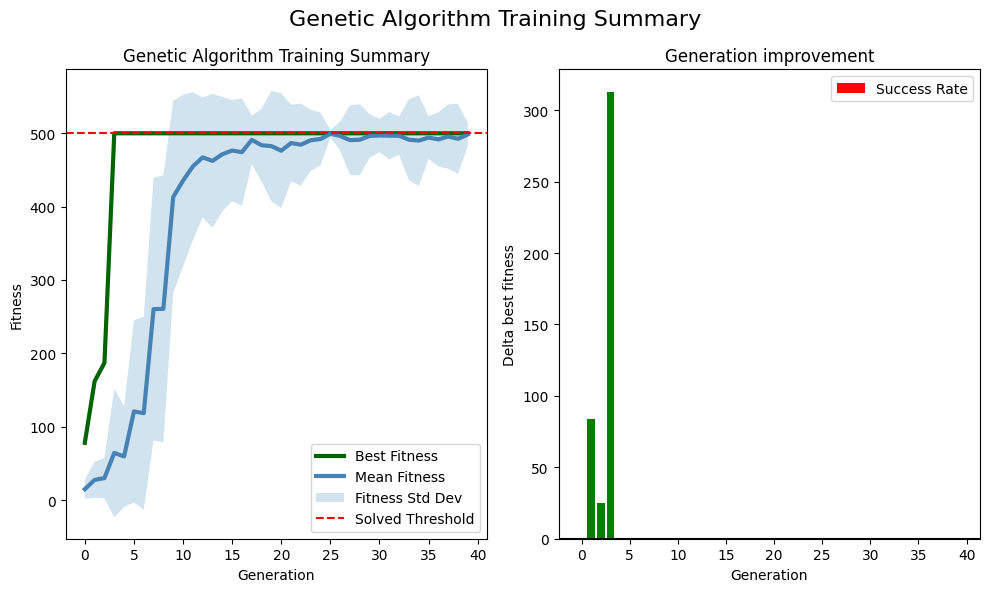

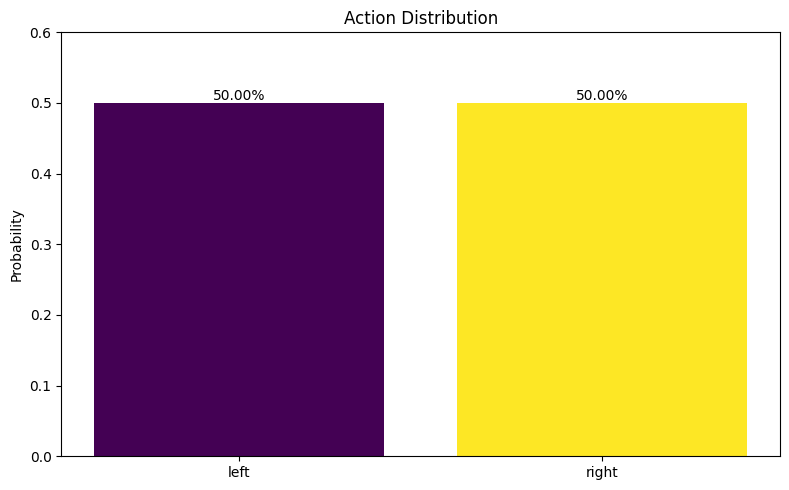

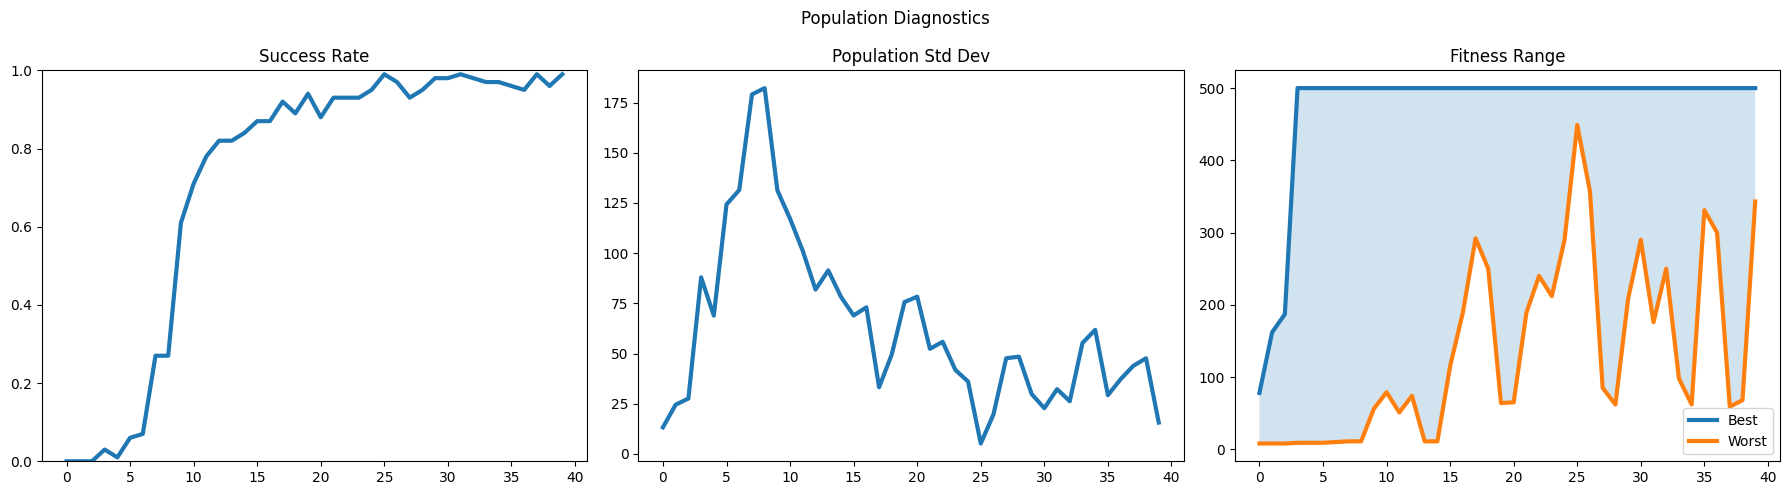

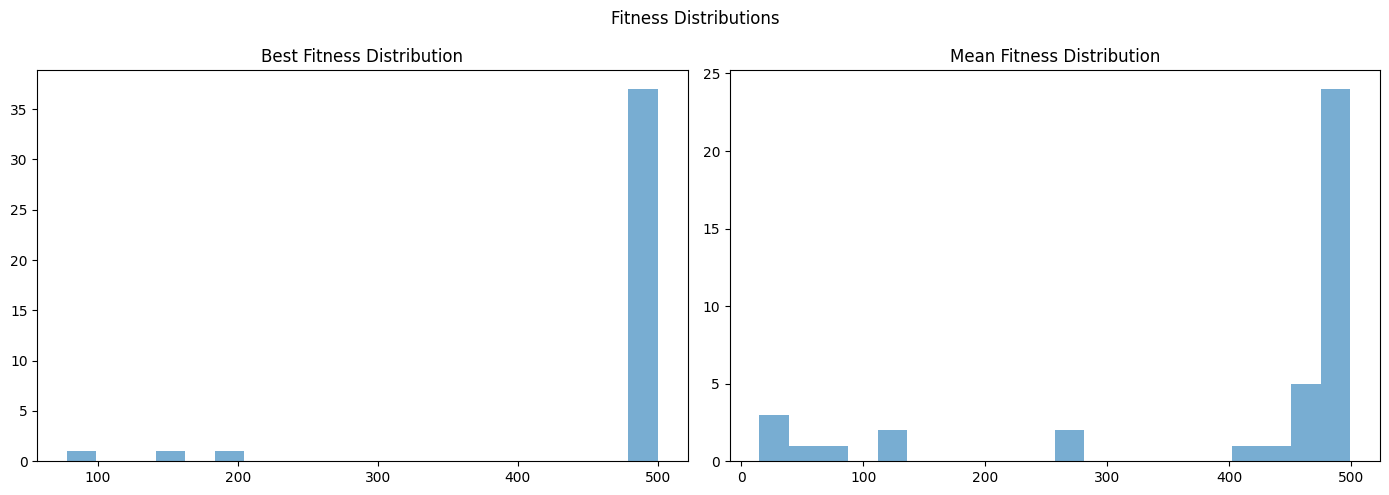

In [118]:
plotter = GeneticAlgorithmPlotter(ga.metrics)

plotter.training_summary(500)
plotter.action_distribution(CARTPOLE_ACTIONS)
plotter.population_diagnostics()
plotter.fitness_distribution()


## CartPole DQN

In [170]:
config = Experiment()
# config.dqn.dqn_episodes = 100 # Uncomment to test with fewer episodes for faster execution during development

env = gym.make("CartPole-v1")
# state_dim = 4 (cart position, cart velocity, pole angle, pole angular velocity)
# action_dim = 2 (left, right)
agent = DQNAgent(state_dim=4, action_dim=2, config=config)

trainer = DQNTrainer(env, agent, config)

trainer.train()

Episode 0 - Reward: 16.00 - Epsilon: 0.995 - Loss: -1.0000
Episode 10 - Reward: 13.00 - Epsilon: 0.946 - Loss: 0.0030
Episode 20 - Reward: 29.00 - Epsilon: 0.900 - Loss: 0.0051
Episode 30 - Reward: 14.00 - Epsilon: 0.856 - Loss: 0.0044
Episode 40 - Reward: 14.00 - Epsilon: 0.814 - Loss: 0.0019
Episode 50 - Reward: 13.00 - Epsilon: 0.774 - Loss: 0.0008
Episode 60 - Reward: 16.00 - Epsilon: 0.737 - Loss: 0.0341
Episode 70 - Reward: 16.00 - Epsilon: 0.701 - Loss: 0.0662
Episode 80 - Reward: 12.00 - Epsilon: 0.666 - Loss: 0.0267
Episode 90 - Reward: 15.00 - Epsilon: 0.634 - Loss: 0.0187
Episode 100 - Reward: 9.00 - Epsilon: 0.603 - Loss: 0.0099
Episode 110 - Reward: 13.00 - Epsilon: 0.573 - Loss: 0.0292
Episode 120 - Reward: 15.00 - Epsilon: 0.545 - Loss: 0.0299
Episode 130 - Reward: 8.00 - Epsilon: 0.519 - Loss: 0.0287
Episode 140 - Reward: 15.00 - Epsilon: 0.493 - Loss: 0.0775
Episode 150 - Reward: 12.00 - Epsilon: 0.469 - Loss: 0.0632
Episode 160 - Reward: 9.00 - Epsilon: 0.446 - Loss: 

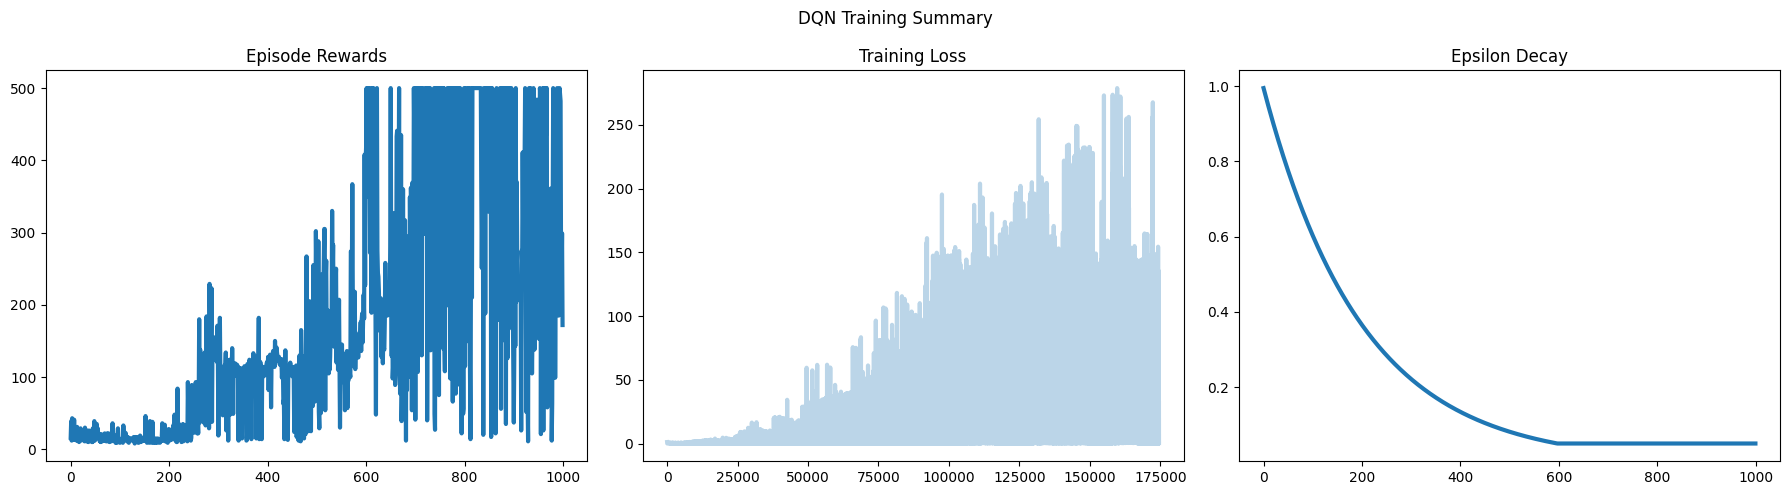

In [171]:
plotter = DQNPlotter(trainer.metrics)

plotter.training_summary(solved_threshold=475)

## Lunar Lander DQN
> Note that I've missclicked the run button of the cell during drafting of md blocks. This execution should work if all is executed from the start.

In [ ]:
env = gym.make("LunarLander-v3")

agent = DQNAgent(state_dim=8, action_dim=4, config=config)

trainer = DQNTrainer(env, agent, config)

trainer.train()

Episode 0 - Reward: -54.92 - Epsilon: 0.995 - Loss: 223.9081
Episode 10 - Reward: -134.27 - Epsilon: 0.946 - Loss: 27.1131


KeyboardInterrupt: 

In [178]:
evaluator = LunarLanderDQNEvaluator(config)
results = evaluator.evaluate(agent)
trainer.metrics.action_distribution = results["action_distribution"]

The DQN agent shows improvement in performance during training.
Early episodes are characterized by highly negative rewards due to random exploration. As training progresses, the average reward increases steadily and converges to values exceeding 200 reward, indicating successful learning of the landing task (where a successful landing is considered near 200 value). However, there still exists some episodes of high spikes near at the end of episodes.
Another important factor is the epsilon decay. As exploration decreases, the agen tries to approach for exploit strategies, resulting in a improvement in the reward metrics, showing more successful landings. 
Also, if we translate to actions, the victorious ones are the main engine and the no-op actions, which both accounts for approximately 74% of all actions. The behaviour is understandable as the landing strategies prioritizes vertical control, the side engines are used less frequently and correct direction during descent.

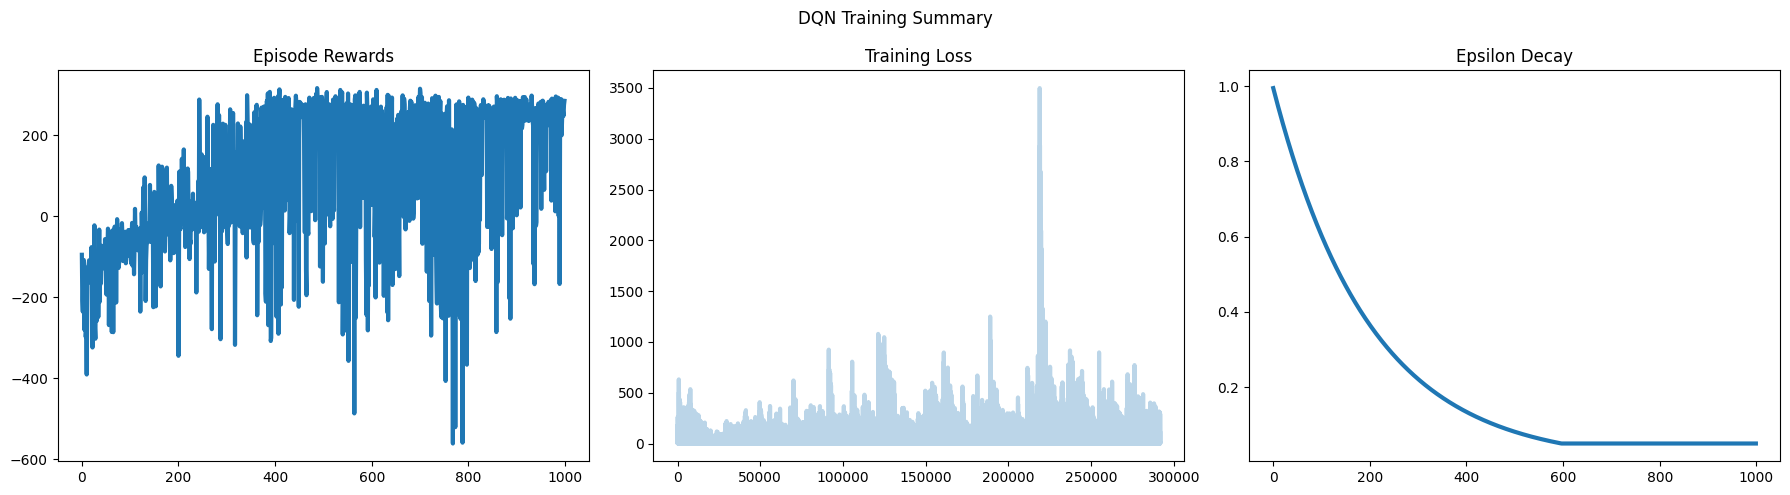

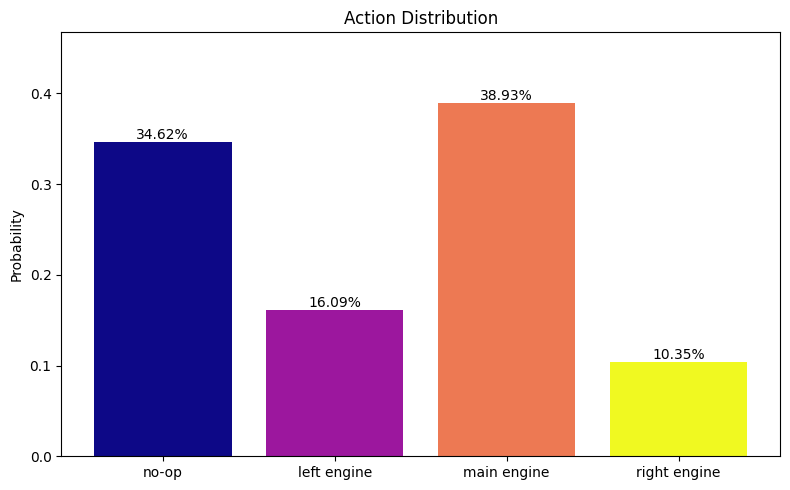

In [179]:
plotter = DQNPlotter(trainer.metrics)
plotter.training_summary(solved_threshold=200)
plotter.action_distribution(LUNAR_ACTIONS)

Test genome flattening and inject

In [181]:
network = PolicyNetwork(state_dim=4, action_dim=2).to(DEVICE)
genome = GenomeUtils.flatten(network)
print("Genome shape:", genome.shape)
# The output value, with 4 -> 128 -> 128 -> 2 architecture, should be:
# (128, 4) = 512
# (128,) = 128
# (128, 128) = 16384
# (128,) = 128
# (2, 128) = 256
# (2,) = 2
# Total = 512 + 128 + 16384 + 128 + 256 + 2 = 17410

Genome shape: (17410,)


In [182]:
network = PolicyNetwork(state_dim=4,action_dim=2).to(DEVICE)

genome = GenomeUtils.flatten(network)

GenomeUtils.inject(network,genome)

genome_after = GenomeUtils.flatten(network)
# The injected genome should be the same as the original genome, so allclose should return True
print(np.allclose(genome,genome_after)
)

True


### CartPole Neural Evaluator (GA)

In [232]:
config = Experiment()
evaluator = CartPoleNeuralEvaluator(config)
network = PolicyNetwork(state_dim=4,action_dim=2).to(DEVICE)
genome_size = len(GenomeUtils.flatten(network))
print("Genome size:", genome_size)

population = Population(size=50,genome_size=genome_size)

ga = GeneticAlgorithm(
    config=config.ga,
    population=population,
    evaluator=evaluator,
    selection=TournamentSelection(5),
    crossover=UniformCrossover(),
    mutation=GaussianMutation(
        mutation_rate=config.ga.ga_mutation_rate,
        mean=0.0,
        stddev=0.1
    )
)

Genome size: 17410


In [233]:
num_generations = 50
# Number of generations to wait for improvement before stopping, without this computations
# can take a long time but with this we can stop early if the algorithm converges to a solution and is not improving anymore
# we must be cautious because we can stop at a local optimum.
patience = 20 
best_so_far = -float("inf")
stagnation = 0

print("Starting Genetic Algorithm training...")

for generation in range(num_generations):

    ga.evaluate_population()

    fitnesses = [
        genome.fitness
        for genome in ga.population.individuals
    ]

    print(
        f"Gen {generation} | "
        f"Best {np.max(fitnesses):.1f} | "
        f"Mean {np.mean(fitnesses):.1f} | "
        f"Worst {np.min(fitnesses):.1f}"
    )
    
    best_in_generation = np.max(fitnesses)
    if best_in_generation > best_so_far:
        best_so_far = best_in_generation
        stagnation = 0
    else:
        stagnation += 1

    if stagnation >= patience:
        print(f"Stopping at generation {generation}")
        break

    ga.evolve()

Starting Genetic Algorithm training...
Gen 0 | Best 87.0 | Mean 17.1 | Worst 8.0
Gen 1 | Best 114.0 | Mean 22.5 | Worst 8.0
Gen 2 | Best 143.0 | Mean 27.0 | Worst 8.0
Gen 3 | Best 210.0 | Mean 37.7 | Worst 8.0
Gen 4 | Best 253.0 | Mean 48.9 | Worst 8.0
Gen 5 | Best 288.0 | Mean 55.6 | Worst 8.0
Gen 6 | Best 346.0 | Mean 73.2 | Worst 8.0
Gen 7 | Best 500.0 | Mean 101.2 | Worst 8.0
Gen 8 | Best 500.0 | Mean 80.4 | Worst 8.0
Gen 9 | Best 500.0 | Mean 95.5 | Worst 9.0
Gen 10 | Best 500.0 | Mean 106.7 | Worst 8.0
Gen 11 | Best 500.0 | Mean 125.6 | Worst 8.0
Gen 12 | Best 500.0 | Mean 197.9 | Worst 9.0
Gen 13 | Best 500.0 | Mean 356.2 | Worst 11.0
Gen 14 | Best 500.0 | Mean 394.4 | Worst 9.0
Gen 15 | Best 500.0 | Mean 418.5 | Worst 9.0
Gen 16 | Best 500.0 | Mean 457.0 | Worst 26.0
Gen 17 | Best 500.0 | Mean 443.0 | Worst 29.0
Gen 18 | Best 500.0 | Mean 445.5 | Worst 23.0
Gen 19 | Best 500.0 | Mean 465.9 | Worst 28.0
Gen 20 | Best 500.0 | Mean 441.1 | Worst 42.0
Gen 21 | Best 500.0 | Mean 484

In [235]:
best_genome = max(
    ga.population.individuals,
    key=lambda genome: genome.fitness
)

results = evaluator.evaluate_policy(
    best_genome
)

print(results)

{'mean_reward': np.float64(500.0), 'std_reward': np.float64(0.0), 'best_reward': np.float64(500.0), 'worst_reward': np.float64(500.0), 'action_distribution': array([0.4999, 0.5001])}


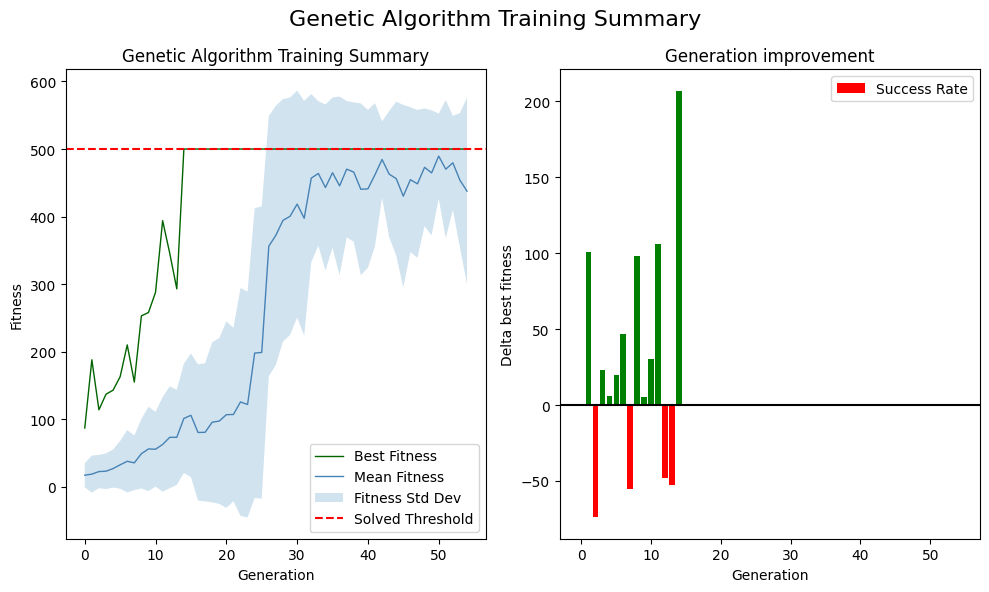

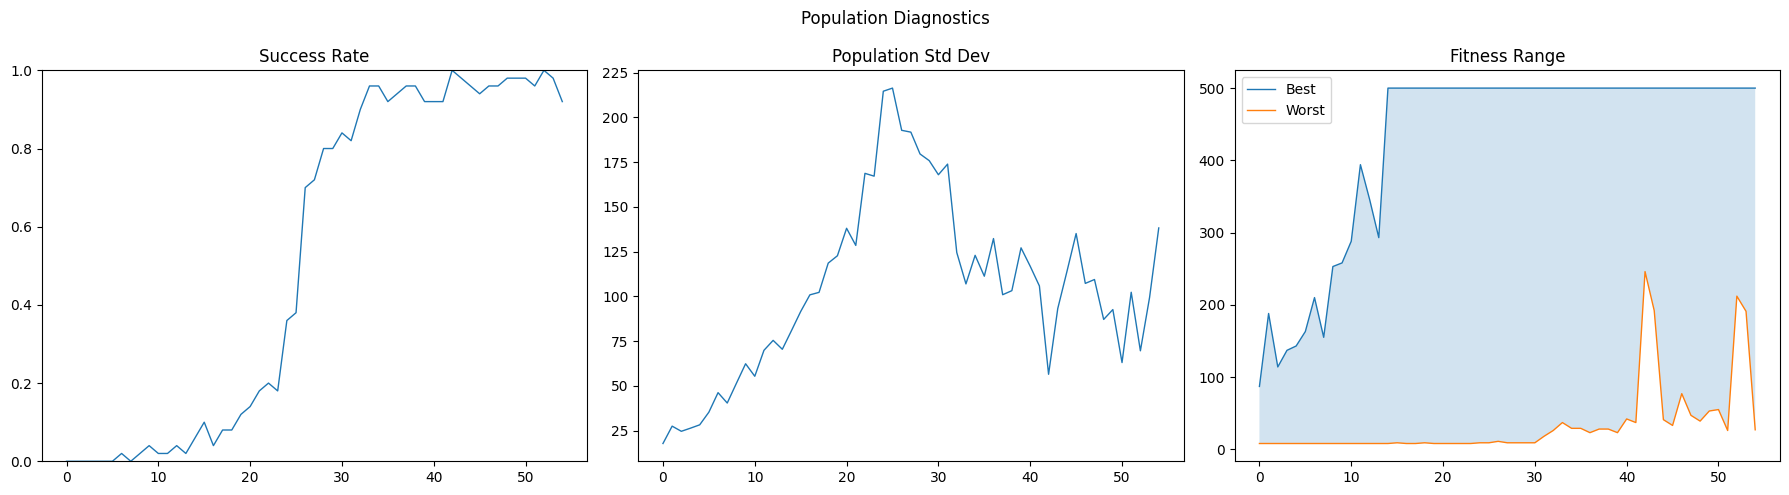

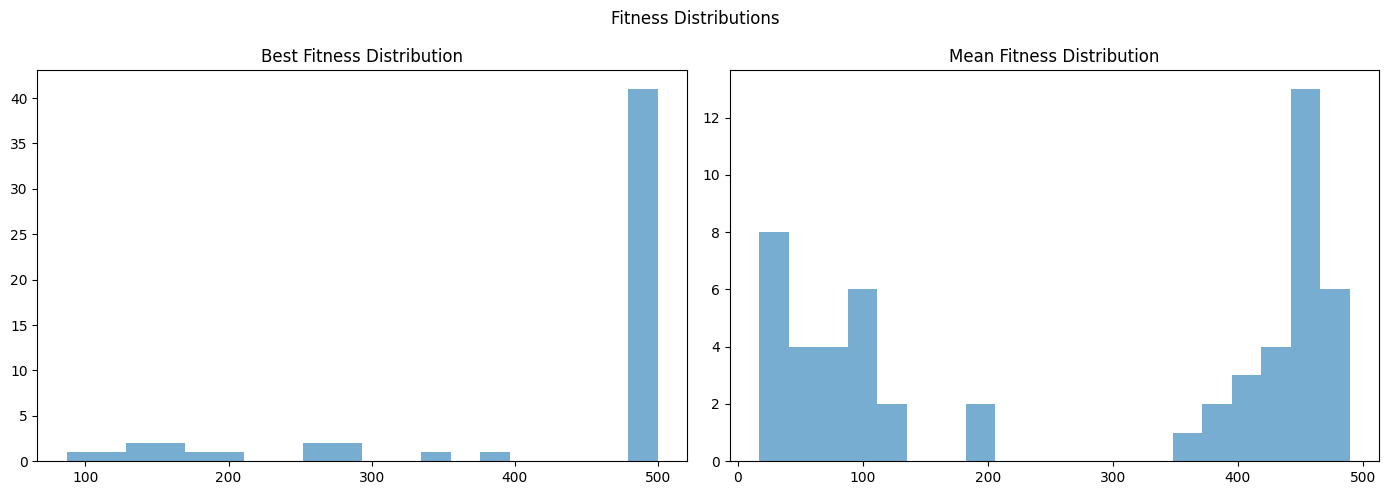

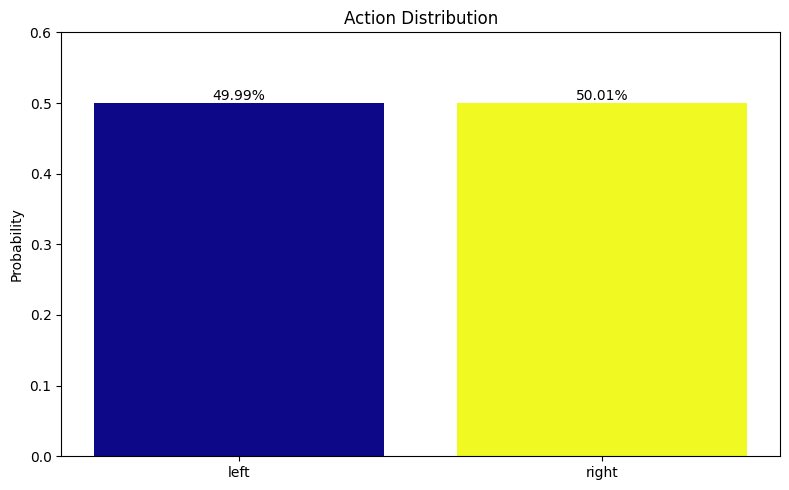

In [236]:
plotter = GeneticAlgorithmPlotter(
    ga.metrics
)

plotter.training_summary(solved_threshold=500)
plotter.population_diagnostics()
plotter.fitness_distribution()
ga.metrics.action_distribution = (results["action_distribution"])
plotter.action_distribution(
    CARTPOLE_ACTIONS
)

In [260]:
# Lunar Lander V3
from numpy import copy


config = Experiment()
evaluator = LunarLanderNeuralEvaluator(config)

network = PolicyNetwork(state_dim=8,action_dim=4,hidden_dim=128).to(DEVICE)
# The genome size should be:
genome_size = len(GenomeUtils.flatten(network))
print("Genome size:", genome_size)
population = Population(size=100, genome_size=genome_size)
num_generations = 150
patience = 30

ga = GeneticAlgorithm(
    config=config.ga,
    population=population,
    evaluator=evaluator,
    selection=TournamentSelection(5), # Select the best out of 5 random individuals
    crossover=UniformCrossover(), # Uniform crossover 
    mutation=GaussianMutation(
        mutation_rate=config.ga.ga_mutation_rate, # Mutation rate of 2% 
        mean=0.0,
        stddev=0.1
    )
)

num_generations = 100
patience = 30
best_so_far = -float("inf")
stagnation = 0

print("Starting Genetic Algorithm training...")

for generation in range(num_generations):

    ga.evaluate_population()

    fitnesses = [
        genome.fitness
        for genome in ga.population.individuals
    ]

    best_fitness = np.max(fitnesses)
    mean_fitness = np.mean(fitnesses)
    worst_fitness = np.min(fitnesses)

    print(
        f"Gen {generation} | "
        f"Best {best_fitness:.1f} | "
        f"Mean {mean_fitness:.1f} | "
        f"Worst {worst_fitness:.1f}"
    )

    if best_fitness > best_so_far:
        best_so_far = best_fitness
        stagnation = 0
    else:
        stagnation += 1

    if stagnation >= patience:
        print(f"Stopping at generation {generation}")
        break

    ga.evolve()

print(f"Best fitness achieved: {best_so_far:.1f}")

Genome size: 18180
Starting Genetic Algorithm training...
Gen 0 | Best -66.7 | Mean -470.4 | Worst -1709.9
Gen 1 | Best -70.0 | Mean -330.7 | Worst -909.8
Gen 2 | Best -62.4 | Mean -320.5 | Worst -992.2
Gen 3 | Best -62.2 | Mean -268.3 | Worst -946.2
Gen 4 | Best -63.8 | Mean -314.8 | Worst -1568.0
Gen 5 | Best -48.2 | Mean -244.3 | Worst -1223.3
Gen 6 | Best -56.1 | Mean -249.5 | Worst -868.2
Gen 7 | Best -33.9 | Mean -235.4 | Worst -810.1
Gen 8 | Best -48.3 | Mean -203.6 | Worst -1006.4
Gen 9 | Best -54.5 | Mean -186.9 | Worst -840.4
Gen 10 | Best -69.2 | Mean -185.1 | Worst -812.6
Gen 11 | Best -50.9 | Mean -178.5 | Worst -900.5
Gen 12 | Best -55.9 | Mean -158.1 | Worst -759.7
Gen 13 | Best -49.6 | Mean -167.8 | Worst -710.7
Gen 14 | Best -51.7 | Mean -192.4 | Worst -1900.3
Gen 15 | Best -39.0 | Mean -177.7 | Worst -3218.6
Gen 16 | Best -44.9 | Mean -160.4 | Worst -876.6
Gen 17 | Best -6.9 | Mean -162.4 | Worst -615.2
Gen 18 | Best -43.0 | Mean -160.6 | Worst -611.3
Gen 19 | Best -2

KeyboardInterrupt: 

> Note that interruption was performed manually.

The Genetic Algorithm was able to learn a successful policy for LunarLander. At the start of training, almost every individual was obtaining highly negative rewards, with the population average below -500 reward. As generations progressed, both the best and average fitness increased. 

Looking at the training curve, the best fitness passed the 200 reward threshold after roughly 100 generations and continued increasing until reaching values close to 300 reward. The mean fitness also improved significantly and eventually became positive, which did not happen in the previous experiment.

The action distribution is also much more balanced than before. The policy still relies mostly on the main engine, but both side engines are used regularly as well. In the previous experiment the agent almost completely ignored lateral corrections, whereas here all actions contribute to the final policy.

The action distribution also suggests that the learned policy was more complete. While the main engine remained the most frequently used action, the agent also made regular use of both side engines. This indicates that the policy learned not only how to reduce vertical speed but also how to correct its position and orientation during descent. The population converged towards successful solutions, the success rate increased consistently, and the final policy made use of all available actions instead of relying on only one or two controls.

{'mean_reward': np.float64(197.51322960239085), 'std_reward': np.float64(105.12992272277648), 'best_reward': np.float64(290.18867253928994), 'worst_reward': np.float64(50.49334643246311), 'success_rate': 0.6666666666666666, 'action_distribution': array([0.22150883, 0.17817014, 0.42375602, 0.17656501])}


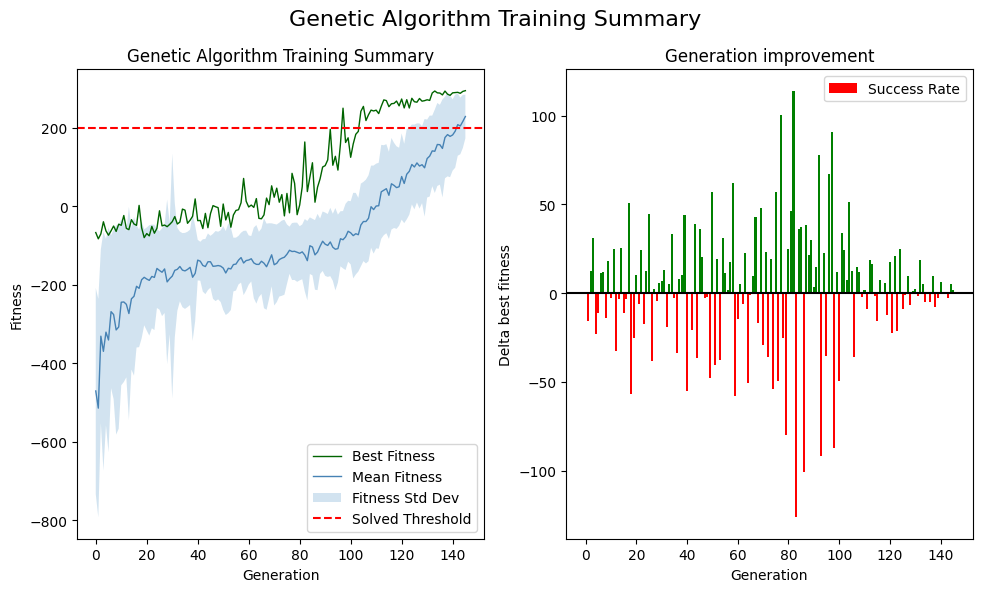

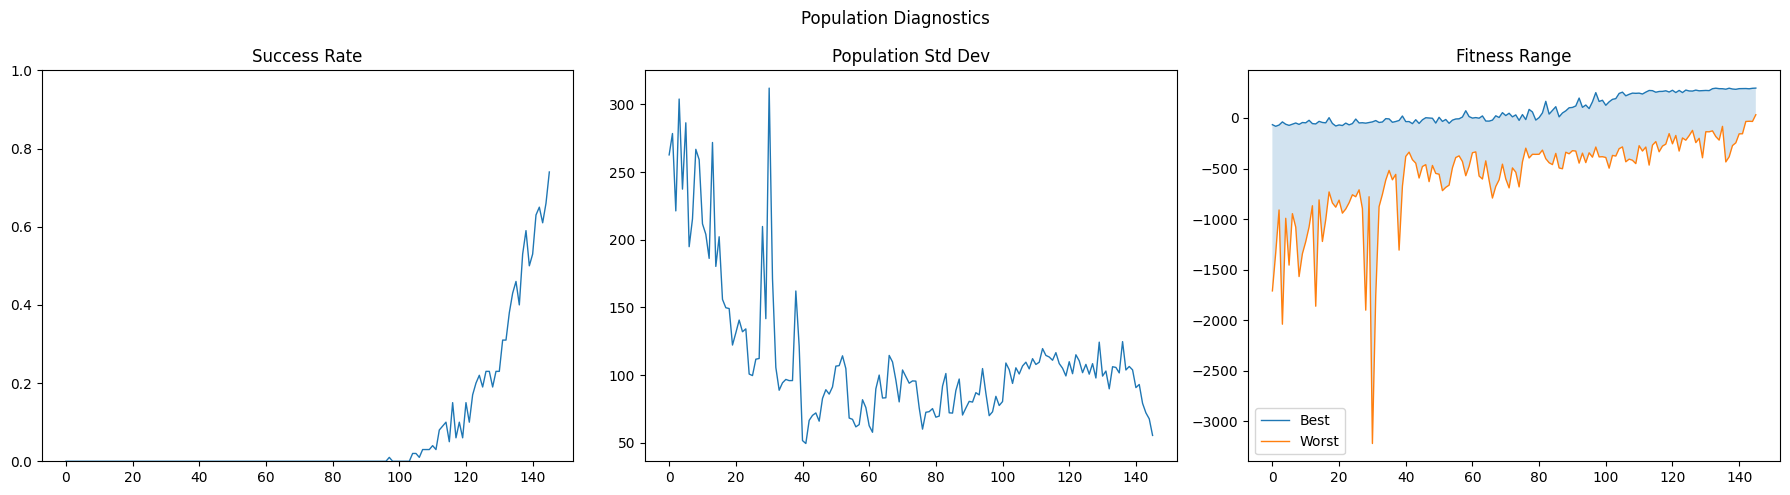

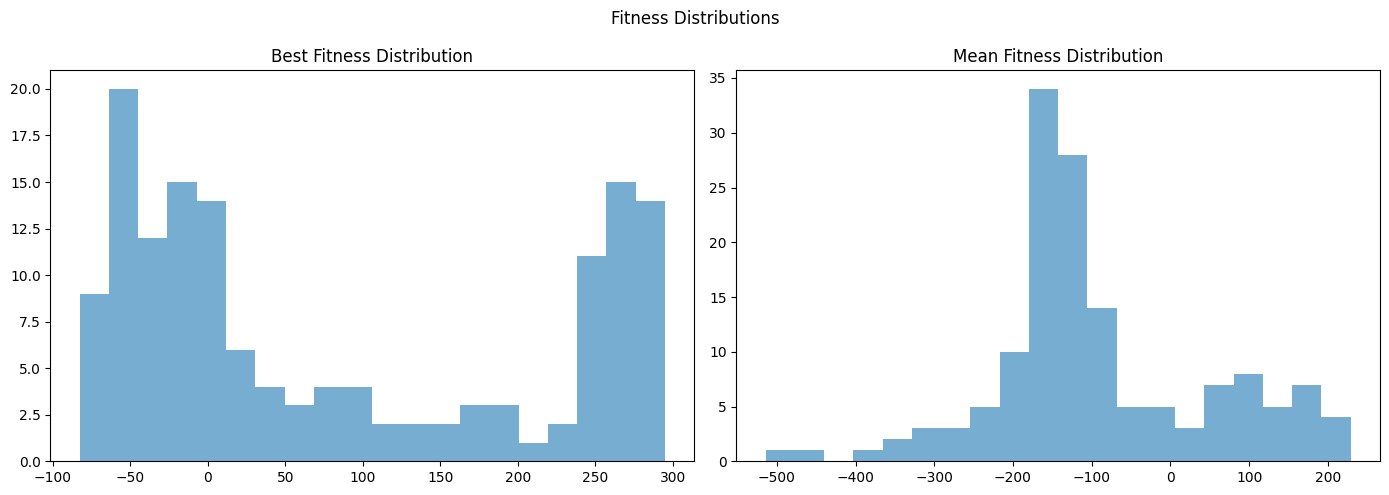

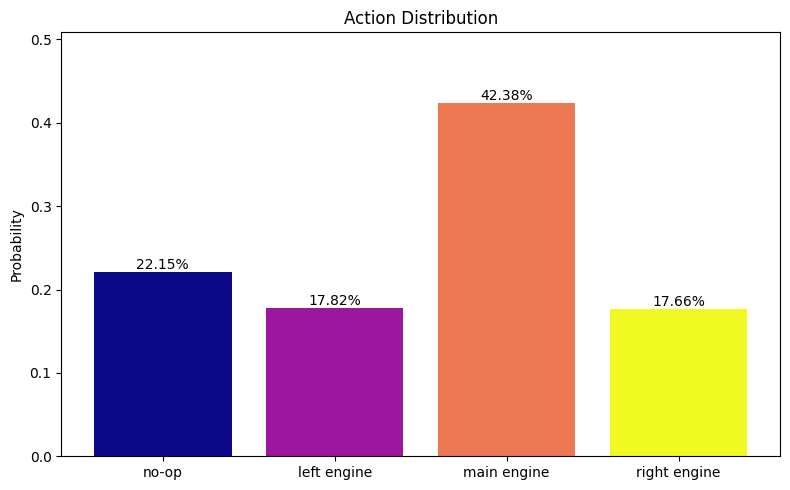

In [261]:
best_genome = max(ga.population.individuals, key=lambda genome: genome.fitness)

results = evaluator.policy_evaluation(best_genome)

print(results)

plotter = GeneticAlgorithmPlotter(ga.metrics)
plotter.training_summary(solved_threshold=200)
plotter.population_diagnostics()
plotter.fitness_distribution()

ga.metrics.action_distribution = results["action_distribution"]

plotter.action_distribution(LUNAR_ACTIONS)

# Evaluation and Comparison

In [263]:
config.eval_episodes = 20

# Genetic Algorithm evaluation

best_genome = max(
    ga.population.individuals,
    key=lambda genome: genome.fitness
)

ga_results = evaluator.policy_evaluation(
    best_genome
)

print("\nGENETIC ALGORITHM")
print(f"Mean Reward : {ga_results['mean_reward']:.2f}")
print(f"Std Reward  : {ga_results['std_reward']:.2f}")
print(f"Best Reward : {ga_results['best_reward']:.2f}")
print(f"Worst Reward: {ga_results['worst_reward']:.2f}")
if "success_rate" in ga_results:
    print(f"Success Rate: {ga_results['success_rate']:.2%}")


# DQN evaluation
agent.epsilon = 0.0
config.dqn.dqn_episodes = 20
dqn_evaluator = LunarLanderDQNEvaluator(config)

results = dqn_evaluator.evaluate(agent)

print("\nDQN FINAL EVALUATION")

print(f"Mean Reward : {results['mean_reward']:.2f}")
print(f"Std Reward  : {results['std_reward']:.2f}")
print(f"Best Reward : {results['best_reward']:.2f}")
print(f"Worst Reward: {results['worst_reward']:.2f}")
print("\nTRAINING METRICS")
print(f"Training Episodes : {config.dqn.dqn_episodes}")
print(f"Environment Steps : {agent.total_steps}")


GENETIC ALGORITHM
Mean Reward : 252.16
Std Reward  : 76.76
Best Reward : 302.33
Worst Reward: 2.50
Success Rate: 90.00%

DQN FINAL EVALUATION
Mean Reward : -5.22
Std Reward  : 11.67
Best Reward : 104.64
Worst Reward: -100.00

TRAINING METRICS
Training Episodes : 20
Environment Steps : 1372


This evaluation show us some results. While the DQN agent showed some improvement during training, this did not translate into strong performance during evaluation.

Over 20 evaluation episodes, the DQN agent achieved a mean reward of -5.22, with a best reward of 104.64. In contrast, the Genetic Algorithm achieved a mean reward of 252.16, a best reward of 302.33, and a success rate of 90%. These results indicate that the Genetic Algorithm was able to learn a much more reliable landing policy for the LunarLander environment. Although the Genetic Algorithm required significantly more computation and longer training times, it ultimately produced the strongest policy in this project. 

This result also highlights the importance of evaluating the final agent rather than relying solely on training curves, as improvements during training do not always correspond to robust performance for testing scenarios.


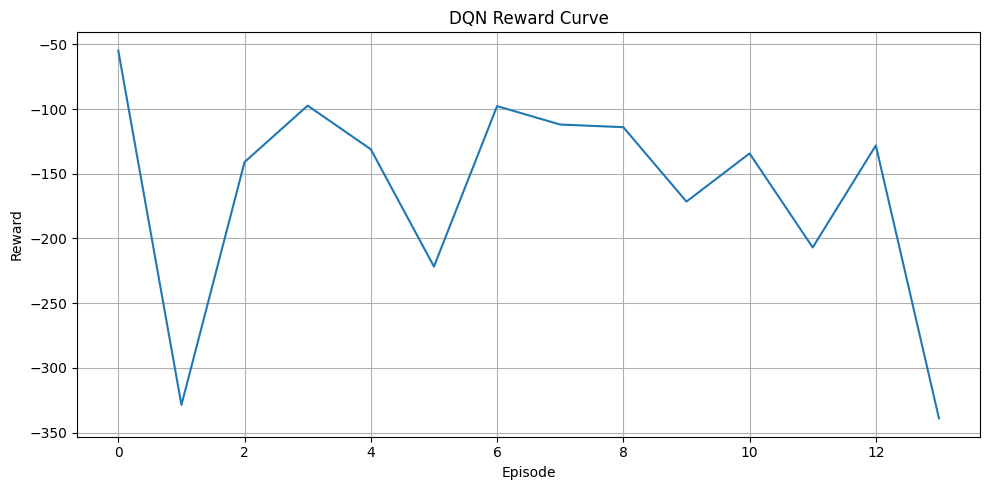

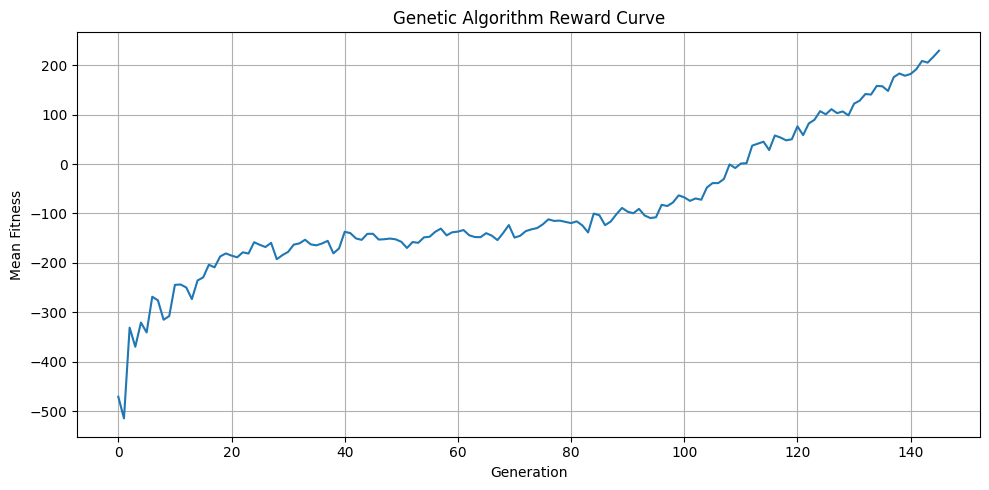

In [266]:
plt.figure(figsize=(10, 5))

plt.plot(
    trainer.metrics.rewards_history
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Reward Curve")

plt.grid(True)

plt.tight_layout()

plt.figure(figsize=(10, 5))

plt.plot(
    ga.metrics.mean_history
)

plt.xlabel("Generation")
plt.ylabel("Mean Fitness")
plt.title("Genetic Algorithm Reward Curve")

plt.grid(True)

plt.tight_layout()
plt.show()

The reward curves show a clear difference between both approaches. The DQN rewards fluctuate considerably and remain mostly negative throughout the evaluation episodes. In contrast, the Genetic Algorithm shows a steady improvement during training, with the mean fitness increasing from approximately -500 reward to values above 200 reward

# Hyper parameter tuning
Due to time limitation in execution time there is no hyperparameter tuning but here is an implementation of how it can be done, using gridsearch approach


# Architectural and Hyperparameter Choices
For both the DQN and Neuroevolution implementations, the same neural network architecture was used to allow a more direct comparison between learning approaches. The network consisted of two hidden layers with 128 neurons and ReLU activation functions.

For CartPole, the network architecture was:
$$
4 \rightarrow 128 \rightarrow 128 \rightarrow 2
$$
For LunarLander, the network architecture was:
$$
8 \rightarrow 128 \rightarrow 128 \rightarrow 4
$$
The Genetic Algorithm used a population size of 100 individuals together with tournament selection, uniform crossover, and Gaussian mutation. A mutation rate of 0.02 was selected and maintained throughout the experiments.
The DQN implementation used experience replay, a target network, and an $\varepsilon$-greedy exploration strategy. Exploration started at $\varepsilon = 1.0$ and decayed throughout training until reaching the minimum exploration rate. The remaining hyperparameters were kept constant during training.

# Reflection

From my perspective, both approaches offer advantages. The GA provides a simpler optimisation framework, which I think is useful when the information available to compute the gradient is not enough or can result in a local optima. This method provide us an advante to almost always find the best solution from the space. However, the experiments from this activity showed that the execution of a GA to obtain a reliable solution can last a lot, making it complicated when the solution space is considerably big, in this case for a simple problem, Lunar Landing, the best experiment lasted +60 minutes, and using GPU acceleration. However, the code can be optimized to run better on GPUs and to enable faster computation of the generation steps. On the other hand, DQN was considerably faster to train and easier to scale. The learning process required less computation time and fewer evaluations than the Genetic Algorithm. However, in this activity, the final DQN policy was not able to achieve the same performance as the Genetic Algorithm in the LunarLander exercise. While the reward curves showed some improvement during training, the final evaluation produced a mean reward of -5.22, compared to 252.16 obtained by the Genetic Algorithm.

In general, I still do not think there is a single approach that is always better. I believe DQN is more computational efficient and faster to train, while GA can be really effective despite the computational cost. In this excersise the GA achieved the best performance. Speaking from personal experience, I am particularly interested in the implementation of heuristic models. I believe that the ability to explore a broader solution space and avoid getting trapped in local optima is a significant advantage. Given the continuous growth in computational power, I think it is worthwhile to invest time in researching solutions that can be fully parallelized across multiple nodes using high-performance computing (HPC) methods. Such approaches could lead to very interesting advancements compared to many of the models currently in use.

Additionally, I would like to explore the application of these methods to machine learning hallucinations, as they may offer more effective ways to mitigate this issue by enabling a more exhaustive search of possible solutions and reducing the likelihood of incorrect outputs.

Additionally, there still parts of the activity pending such as the hyperparameter tuning but with the modularity of the code this should be easy to implement. 